<div style="background:linear-gradient(135deg, rgba(249,112,102,0.18), rgba(249,112,102,0.02)); border-left:6px solid #F97066; border-radius:10px; padding:20px 24px; margin-bottom:20px;">
<h1 style="margin:0; color:#F97066; font-size:1.8em;">🧠 Fundamentos de Redes Neuronales Artificiales</h1>
<p style="margin:6px 0 0; opacity:0.8;">Unidad 4 — De la neurona artificial al entrenamiento con Keras</p>
</div>

Este notebook presenta los fundamentos de las redes neuronales artificiales (ANN): qué es una neurona artificial, cómo se combinan en capas, qué papel cumplen las funciones de activación, y cómo se entrena una red mediante descenso de gradiente y retropropagación (*backpropagation*). Se apoya en conceptos ya vistos en la Unidad 3: el producto punto y las matrices de <code>../Unidad 3/1-AI-fundamentals/1-algebra-lineal-ML.ipynb</code>, y el descenso de gradiente de <code>../Unidad 3/1-AI-fundamentals/2-gradiente-descendiente.ipynb</code>.

Las arquitecturas específicas — redes convolucionales, modelos secuenciales, procesamiento de lenguaje natural y Transformers — se profundizan cada una en su propio notebook, indicado al final de este.

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0 24px; background:rgba(14,165,233,0.04);">
<strong>📑 Contenido de esta guía</strong>
<ol style="margin:8px 0 0; padding-left:20px;">
<li><a href="#que-es-una-rna">¿Qué es una red neuronal artificial?</a></li>
<li><a href="#neurona-artificial">La neurona artificial: combinación lineal y activación</a></li>
<li><a href="#funciones-activacion">Funciones de activación</a></li>
<li><a href="#entrenamiento">Entrenamiento: función de pérdida y descenso de gradiente</a></li>
<li><a href="#ejemplo-keras">Ejemplo completo: clasificación de dígitos con Keras</a></li>
<li><a href="#sobreajuste-subajuste">Sobreajuste y subajuste</a></li>
<li><a href="#cierre">Cierre y próximos pasos</a></li>
</ol>
</div>

<a id="que-es-una-rna"></a>

## <span style="color:#F97066;">¿Qué es una red neuronal artificial?</span>

Una red neuronal artificial (RNA, o *ANN* por sus siglas en inglés) es un modelo compuesto por unidades simples — neuronas artificiales — organizadas en capas:

- **Capa de entrada**: recibe las variables del problema (por ejemplo, los 64 valores de intensidad de una imagen de 8×8 píxeles que representa un dígito escrito a mano).
- **Capas ocultas**: una o más capas intermedias donde ocurre la mayor parte del cómputo. Cuantas más capas ocultas tiene una red, más "profunda" se considera (de ahí el término *deep learning*).
- **Capa de salida**: produce el resultado final (por ejemplo, la probabilidad de cada una de las 3 especies de Iris).

Cada conexión entre neuronas tiene asociado un **peso**, y cada neurona tiene un **sesgo** (*bias*). Entrenar una red neuronal consiste, precisamente, en encontrar los valores de esos pesos y sesgos que hacen que la red produzca las salidas correctas.

<a id="neurona-artificial"></a>

## <span style="color:#F97066;">La neurona artificial: combinación lineal y activación</span>

Cada neurona realiza dos pasos:

1. Una **combinación lineal** de sus entradas: multiplica cada entrada $x_i$ por su peso $w_i$, suma los resultados y le agrega el sesgo $b$. Esto es exactamente el producto punto $w \cdot x$ visto en <code>1-algebra-lineal-ML.ipynb</code>:

$$z = w \cdot x + b = \sum_{i=1}^n w_i x_i + b$$

2. Una **función de activación** $f$ aplicada sobre $z$, que introduce no linealidad: $\text{salida} = f(z)$.

Sin la función de activación, apilar muchas capas sería matemáticamente equivalente a una sola capa lineal (la composición de funciones lineales es lineal), y la red no podría aprender relaciones complejas.

A continuación, se calcula manualmente la salida de una neurona con una entrada y pesos arbitrarios, y se compara con el resultado de una capa <code>Dense</code> de Keras a la que se le asignan esos mismos pesos — para comprobar que es exactamente el mismo cálculo.

In [1]:
import numpy as np
import tensorflow as tf

# Entrada y parámetros de una neurona (valores arbitrarios, solo para el ejemplo)
x = np.array([1.5, -0.3, 2.0])
w = np.array([0.4, 0.8, 0.3])
b = 0.5

# 1. Cálculo manual: combinación lineal + activación ReLU
z = np.dot(w, x) + b
salida_relu = max(0, z)
print(f"z = w·x + b = {z:.3f}")
print(f"ReLU(z) = {salida_relu:.3f}")

# 2. El mismo cálculo con una capa Dense de Keras, fijando manualmente sus pesos
capa = tf.keras.layers.Dense(1, activation="relu")
capa.build(input_shape=(3,))
capa.set_weights([w.reshape(3, 1), np.array([b])])
salida_keras = capa(x.reshape(1, 3)).numpy()[0, 0]
print(f"Salida de la capa Dense de Keras: {salida_keras:.3f}")

z = w·x + b = 1.460
ReLU(z) = 1.460
Salida de la capa Dense de Keras: 1.460


<a id="funciones-activacion"></a>

## <span style="color:#F97066;">Funciones de activación</span>

Las funciones de activación más comunes en capas ocultas son:

- **Sigmoid**: comprime cualquier valor al rango (0, 1). Históricamente muy usada, pero en redes profundas sufre el problema del **gradiente que desaparece** (*vanishing gradient*): para valores muy grandes o muy pequeños de $z$, su derivada es casi 0, por lo que el gradiente que se propaga hacia atrás durante el entrenamiento se vuelve extremadamente pequeño.
- **Tanh**: similar a sigmoid, pero centrada en 0 (rango -1 a 1), lo que suele acelerar el entrenamiento respecto a sigmoid, aunque sufre el mismo problema del gradiente que desaparece en los extremos.
- **ReLU** (*Rectified Linear Unit*): $f(z) = \max(0, z)$. Es la más usada en capas ocultas hoy en día porque es muy simple de calcular y su derivada es 0 o 1 — no se "aplana" para valores grandes de $z$, lo que mitiga en gran medida el problema del gradiente que desaparece.

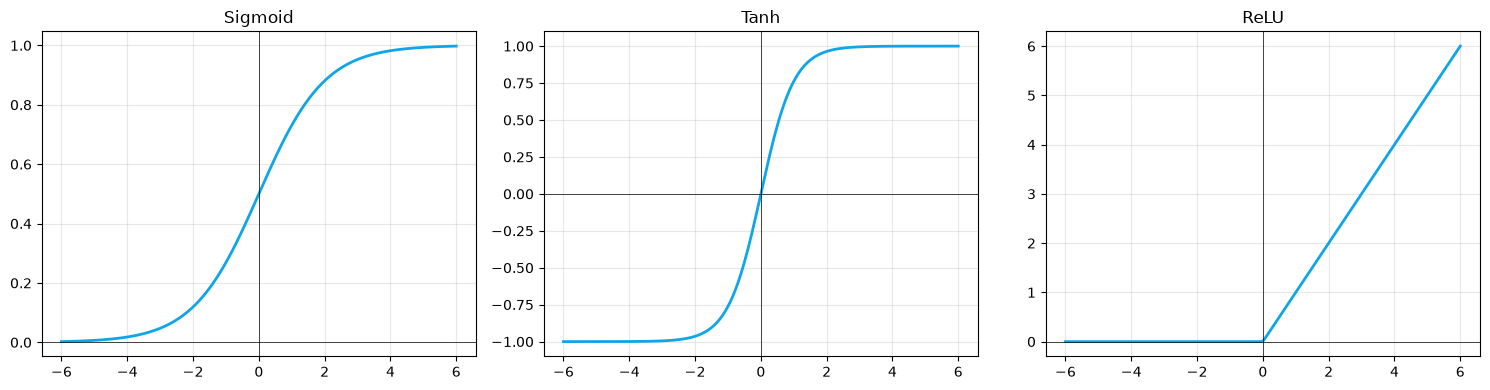

In [2]:
import matplotlib.pyplot as plt

z = np.linspace(-6, 6, 200)
sigmoid = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
relu = np.maximum(0, z)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, curva, nombre in zip(axes, [sigmoid, tanh, relu], ["Sigmoid", "Tanh", "ReLU"]):
    ax.plot(z, curva, color="#0EA5E9", linewidth=2)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_title(nombre)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

En la **capa de salida**, la elección depende del tipo de problema:

- **Sigmoid**: clasificación binaria (una sola salida, interpretada como probabilidad).
- **Softmax**: clasificación multiclase. Convierte un vector de valores arbitrarios (*logits*) en una distribución de probabilidad: todos los valores quedan entre 0 y 1, y suman exactamente 1.

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$$

In [3]:
logits = np.array([2.0, 1.0, 0.1])
exp = np.exp(logits - np.max(logits))  # se resta el máximo por estabilidad numérica
probabilidades = exp / exp.sum()

print(f"Logits: {logits}")
print(f"Softmax: {np.round(probabilidades, 3)}")
print(f"Suma de las probabilidades: {probabilidades.sum():.3f}")

Logits: [2.  1.  0.1]
Softmax: [0.659 0.242 0.099]
Suma de las probabilidades: 1.000


<a id="entrenamiento"></a>

## <span style="color:#F97066;">Entrenamiento: función de pérdida y descenso de gradiente</span>

Entrenar una red neuronal significa ajustar todos sus pesos y sesgos para que, dada una entrada, la salida se acerque lo más posible al valor esperado. El proceso, en cada iteración (*época*), consta de cuatro pasos:

1. **Propagación hacia adelante** (*forward pass*): la entrada atraviesa la red, capa por capa, hasta producir una salida.
2. **Función de pérdida** (*loss*): compara la salida de la red con el valor real y produce un único número que mide qué tan equivocada estuvo la red. Para clasificación multiclase con salida softmax, la función usual es la **entropía cruzada categórica** (<code>categorical_crossentropy</code>).
3. **Retropropagación** (*backpropagation*): usando la regla de la cadena del cálculo diferencial, se calcula el gradiente de la función de pérdida respecto a **cada** peso y sesgo de la red — es decir, cuánto y en qué dirección debería cambiar cada parámetro para reducir el error.
4. **Descenso de gradiente**: cada peso se actualiza dando un pequeño paso en la dirección opuesta a su gradiente, tal como se vio en <code>2-gradiente-descendiente.ipynb</code> — solo que aquí, en lugar de dos o tres parámetros, se actualizan simultáneamente todos los pesos y sesgos de la red (que pueden ser miles o millones).

Este ciclo se repite durante muchas épocas hasta que la pérdida deja de disminuir de forma significativa.

<a id="ejemplo-keras"></a>

## <span style="color:#F97066;">Ejemplo completo: clasificación de dígitos con Keras</span>

A continuación, se construye, entrena y evalúa una red neuronal completa con Keras sobre el dataset **Digits** de scikit-learn: 1797 imágenes de 8×8 píxeles de dígitos escritos a mano (0 al 9), cada una aplanada en un vector de 64 valores de intensidad.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Un dataset como Iris (4 variables, 3 clases perfectamente separables) resulta demasiado sencillo para una red neuronal: casi cualquier arquitectura llega a una precisión cercana al 100&nbsp;% en pocas épocas, sin dejar ver matices del entrenamiento ni margen para observar sobreajuste. Digits, con 10 clases y 64 variables, exige más de la red y deja el margen necesario para la siguiente sección de este notebook.
</div>

La red usa activación **ReLU** en las capas ocultas y **softmax** en la capa de salida, junto con la función de pérdida <code>categorical_crossentropy</code> — exactamente los conceptos presentados en las secciones anteriores.

<span style="color:#F97066;">1.</span> Preparación de los datos y construcción del modelo

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report

# 1. Cargar datos
digits = load_digits()
X, y = digits.data, digits.target.reshape(-1, 1)
print(f"Forma de X: {X.shape} (1797 imágenes de 8x8 píxeles, aplanadas a 64 valores)")

# 2. Escalamiento de características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. One-hot encoding para las etiquetas
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

# 4. División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y
)

# 5. Construcción del modelo ANN
model = Sequential([
    Input(shape=(X.shape[1],)),       # 64 características de entrada
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),     # Capa oculta con 16 neuronas
    Dense(10, activation="softmax"),  # 10 clases (dígitos 0-9)
])

model.summary()

Forma de X: (1797, 64) (1797 imágenes de 8x8 píxeles, aplanadas a 64 valores)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,778 (10.85 KB)

 Trainable params: 2,778 (10.85 KB)

 Non-trainable params: 0 (0.00 B)

<span style="color:#F97066;">2.</span> Compilar y entrenar el modelo

In [5]:
# 6. Compilar modelo
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# 7. Entrenar modelo
history = model.fit(
    X_train, y_train, epochs=60, batch_size=16, verbose=0, validation_split=0.2
)

# 8. Evaluar modelo
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nPrecisión en test: {acc:.3f}")

# 9. Predicciones y reporte
y_pred = model.predict(X_test, verbose=0)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print(
    "\nReporte de clasificación:\n",
    classification_report(y_true_labels, y_pred_labels),
)


Precisión en test: 0.978

Reporte de clasificación:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        54
           1       0.96      0.98      0.97        55
           2       0.98      0.96      0.97        53
           3       0.98      0.98      0.98        55
           4       0.98      0.98      0.98        54
           5       0.98      0.98      0.98        55
           6       1.00      1.00      1.00        54
           7       1.00      1.00      1.00        54
           8       0.94      0.92      0.93        52
           9       0.95      0.98      0.96        54

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



<span style="color:#F97066;">3.</span> Visualización del entrenamiento

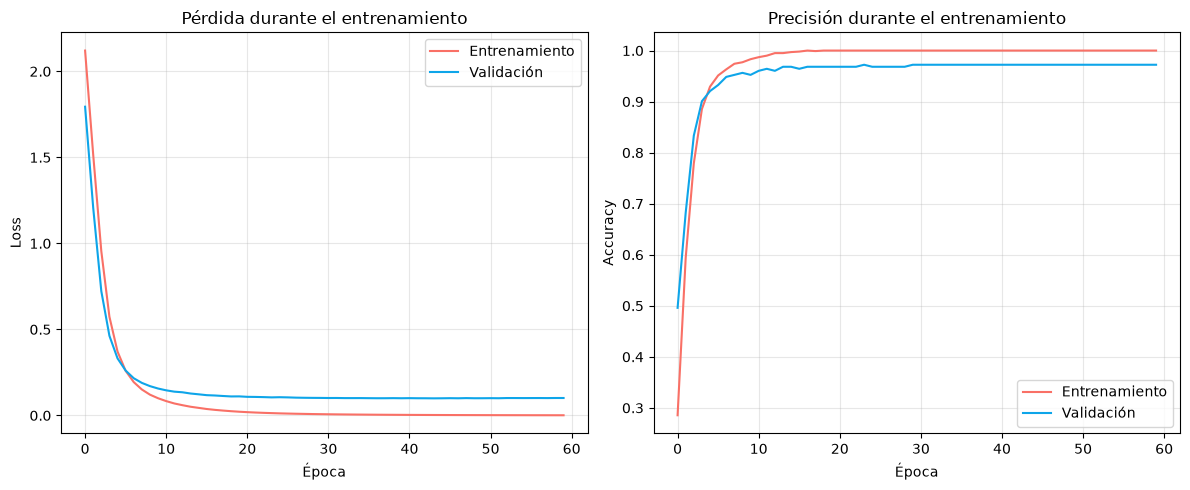

Precisión final — entrenamiento: 1.000, validación: 0.972


In [6]:
# Visualizar evolución de la pérdida y la precisión durante el entrenamiento
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], color="#F97066", label="Entrenamiento")
plt.plot(history.history["val_loss"], color="#0EA5E9", label="Validación")
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], color="#F97066", label="Entrenamiento")
plt.plot(history.history["val_accuracy"], color="#0EA5E9", label="Validación")
plt.title("Precisión durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Precisión final — entrenamiento: {history.history['accuracy'][-1]:.3f}, validación: {history.history['val_accuracy'][-1]:.3f}")

<a id="sobreajuste-subajuste"></a>

## <span style="color:#F97066;">Sobreajuste y subajuste</span>

El ejemplo anterior entrena razonablemente bien: al final, la precisión de entrenamiento y de validación quedan relativamente cerca. Pero esa cercanía no está garantizada — es, de hecho, uno de los mayores riesgos al entrenar cualquier red neuronal. Conviene distinguir dos formas en que un modelo puede fallar:

- **Subajuste** (*underfitting*): el modelo es demasiado simple (o se entrena muy poco) para capturar los patrones presentes incluso en los datos de entrenamiento. Síntoma: la precisión de entrenamiento **y** de validación son ambas bajas, y ninguna mejora mucho así se entrene más tiempo.
- **Sobreajuste** (*overfitting*): el modelo tiene capacidad de sobra respecto a la cantidad de datos disponibles, y termina memorizando particularidades del conjunto de entrenamiento (incluido su ruido) en lugar de aprender un patrón que generalice. Síntoma: la precisión de entrenamiento sigue subiendo (o la pérdida sigue bajando) mientras la de validación se estanca o empeora — la brecha entre ambas curvas crece con las épocas.

A continuación, se fuerzan deliberadamente ambos escenarios sobre el mismo dataset Digits, para ver sus síntomas de forma inequívoca.

<span style="color:#F97066;">1.</span> Forzando el sobreajuste: mucha capacidad, muy pocos datos

Se entrena una red bastante más grande que la anterior (dos capas de 128 neuronas) usando solo 100 imágenes de entrenamiento — una fracción mínima de las 1257 disponibles — durante 150 épocas.

In [7]:
# 1. Tomar un subconjunto muy pequeño del conjunto de entrenamiento (100 de 1257 imágenes)
X_train_chico, _, y_train_chico, _ = train_test_split(
    X_train, y_train, train_size=100, random_state=42, stratify=y_train.argmax(axis=1)
)
print(f"Imágenes usadas para entrenar el modelo sobreajustado: {X_train_chico.shape[0]}")

# 2. Modelo con mucha más capacidad (128+128 neuronas) que la usada en el ejemplo anterior
modelo_sobreajustado = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(128, activation="relu"),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax"),
])
modelo_sobreajustado.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# 3. Entrenar muchas épocas sobre muy pocos datos, validando contra el conjunto de prueba completo
historial_sobreajuste = modelo_sobreajustado.fit(
    X_train_chico, y_train_chico,
    epochs=150, batch_size=8, verbose=0,
    validation_data=(X_test, y_test),
)

print(f"Precisión final — entrenamiento: {historial_sobreajuste.history['accuracy'][-1]:.3f}, "
      f"validación: {historial_sobreajuste.history['val_accuracy'][-1]:.3f}")
print(f"Pérdida final — entrenamiento: {historial_sobreajuste.history['loss'][-1]:.4f}, "
      f"validación: {historial_sobreajuste.history['val_loss'][-1]:.4f}")

Imágenes usadas para entrenar el modelo sobreajustado: 100


Precisión final — entrenamiento: 1.000, validación: 0.896
Pérdida final — entrenamiento: 0.0002, validación: 0.3636


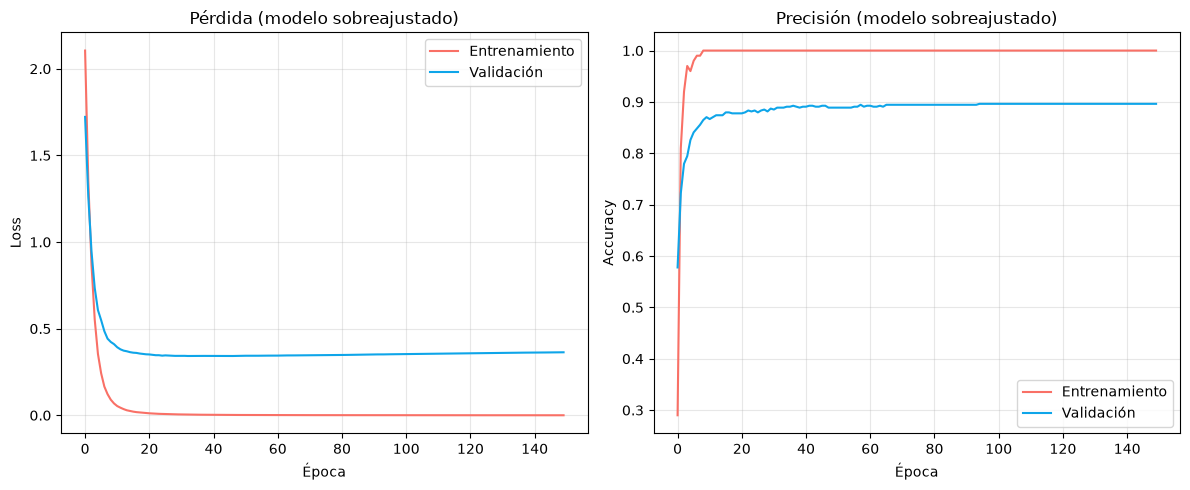

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(historial_sobreajuste.history["loss"], color="#F97066", label="Entrenamiento")
plt.plot(historial_sobreajuste.history["val_loss"], color="#0EA5E9", label="Validación")
plt.title("Pérdida (modelo sobreajustado)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historial_sobreajuste.history["accuracy"], color="#F97066", label="Entrenamiento")
plt.plot(historial_sobreajuste.history["val_accuracy"], color="#0EA5E9", label="Validación")
plt.title("Precisión (modelo sobreajustado)")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

La brecha es evidente: la pérdida de entrenamiento cae prácticamente a cero (la red memoriza las 100 imágenes que vio), mientras que la pérdida de validación se estabiliza en un valor mucho más alto — y la precisión de validación queda muy por debajo de la de entrenamiento. La red no está aprendiendo a reconocer dígitos en general; está memorizando 100 ejemplos particulares.

<span style="color:#F97066;">2.</span> Forzando el subajuste: muy poca capacidad

En el otro extremo, se entrena una red con una sola capa oculta de apenas 2 neuronas — muy por debajo de lo necesario para separar 10 clases — sobre el conjunto de entrenamiento completo.

In [9]:
# 1. Modelo con capacidad insuficiente: una sola capa oculta de 2 neuronas
modelo_subajustado = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(2, activation="relu"),
    Dense(10, activation="softmax"),
])
modelo_subajustado.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# 2. Esta vez sí se usa todo el conjunto de entrenamiento disponible
historial_subajuste = modelo_subajustado.fit(
    X_train, y_train,
    epochs=60, batch_size=16, verbose=0,
    validation_data=(X_test, y_test),
)

print(f"Precisión final — entrenamiento: {historial_subajuste.history['accuracy'][-1]:.3f}, "
      f"validación: {historial_subajuste.history['val_accuracy'][-1]:.3f}")

Precisión final — entrenamiento: 0.588, validación: 0.581


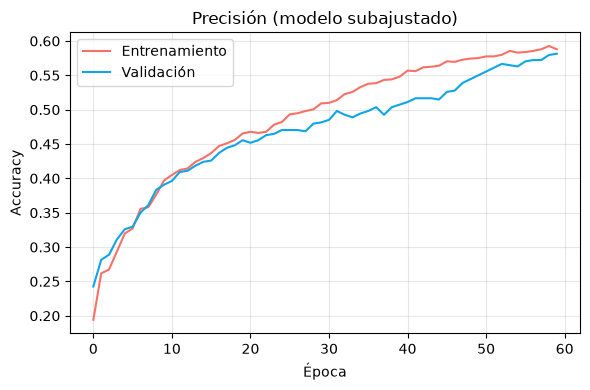

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(historial_subajuste.history["accuracy"], color="#F97066", label="Entrenamiento")
plt.plot(historial_subajuste.history["val_accuracy"], color="#0EA5E9", label="Validación")
plt.title("Precisión (modelo subajustado)")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Aquí el síntoma es opuesto al anterior: entrenamiento y validación quedan muy cerca entre sí, pero **ambas bajas** — no hay brecha porque el modelo ni siquiera logra ajustar bien los datos que ya vio. Con solo 2 neuronas en la capa oculta, la red no tiene capacidad suficiente para separar 10 clases de dígitos, sin importar cuántas épocas se entrene.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Los tres modelos entrenados en este notebook — el original, el sobreajustado y el subajustado — comparten la misma arquitectura general y el mismo dataset; solo cambian la cantidad de datos de entrenamiento y el número de neuronas. Esa es precisamente la idea: sobreajuste y subajuste no son propiedades de un algoritmo, sino del <em>balance</em> entre la capacidad del modelo y la cantidad de datos disponibles. Técnicas como <code>Dropout</code>, el aumento de datos y la transferencia de aprendizaje — vistas en <code>3-redes-convolucionales.ipynb</code> — son, en el fondo, distintas formas de corregir ese balance cuando se dispone de pocos datos frente a un modelo grande.
</div>

---

<a id="cierre"></a>

# <span style="color:#F97066;">🎯 Cierre y próximos pasos</span>

<div style="border-left:4px solid #14B8A6; background:rgba(20,184,166,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>✅ Resumen</strong><br>
Este notebook presentó los fundamentos de las redes neuronales artificiales:

- Arquitectura de una red: capas de entrada, ocultas y de salida; pesos y sesgos.
- La neurona artificial como combinación lineal (producto punto) seguida de una función de activación.
- Funciones de activación (sigmoid, tanh, ReLU, softmax) y por qué ReLU domina en capas ocultas.
- El ciclo de entrenamiento: propagación hacia adelante, función de pérdida, retropropagación y descenso de gradiente.
- Un ejemplo completo con Keras sobre el dataset Digits.
- Sobreajuste y subajuste: sus síntomas opuestos en las curvas de entrenamiento/validación, forzados deliberadamente sobre el mismo dataset.

</div>

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0; background:rgba(14,165,233,0.04);">
<strong>🔎 Profundice en cada arquitectura</strong>
<p style="margin:8px 0;">Digits ya deja ver sobreajuste y subajuste con claridad, pero las arquitecturas modernas de redes neuronales se entienden mejor sobre datos aún más ricos y específicos de cada dominio (imágenes con estructura espacial, series de tiempo, texto). Los siguientes notebooks profundizan cada arquitectura:</p>
<ul style="margin:8px 0 0; padding-left:20px;">
<li><code>3-redes-convolucionales.ipynb</code> — CNN: filtros aprendidos, regularización (Dropout), aumento de datos y transferencia de aprendizaje.</li>
<li><code>4-modelos-secuenciales.ipynb</code> — RNN, LSTM y GRU sobre series de tiempo, y por qué las puertas de LSTM resuelven el problema del gradiente que desaparece.</li>
<li><code>5-procesamiento-lenguaje-natural.ipynb</code> — Procesamiento de Lenguaje Natural: de TF-IDF a *embeddings* entrenables, y clasificación de texto.</li>
<li><code>6-transformers.ipynb</code> — el mecanismo de *self-attention* y el uso de modelos preentrenados de Hugging Face.</li>
</ul>
</div>

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0; background:rgba(14,165,233,0.04);">
<strong>➡️ Continúe con</strong>
<ul style="margin:8px 0 0; padding-left:20px;">
<li><code>2-vision-por-computador.ipynb</code> — antes de construir una red convolucional (CNN), conviene entender cómo se representa una imagen dentro de una computadora y qué es, exactamente, una convolución.</li>
</ul>
</div>